<a href="https://colab.research.google.com/github/A-D-Vargas/PI_Mineria_Datos_1/blob/main/2_notebooks/04_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Se desarrolla en 04_pca.ipynb. Documentar las variables utilizadas, escalamiento aplicado, la varianza explicada y la interpretación de las componentes obtenidas.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


url = "https://raw.githubusercontent.com/A-D-Vargas/PI_Mineria_Datos_1/refs/heads/main/1_data/processed/streaming_users_limpio.csv"
df = pd.read_csv(url)

df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,1.0
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2.0
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0.0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0.0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1.0


Componente 1: 33.57% de varianza
Componente 2: 33.40% de varianza
Componente 3: 33.03% de varianza


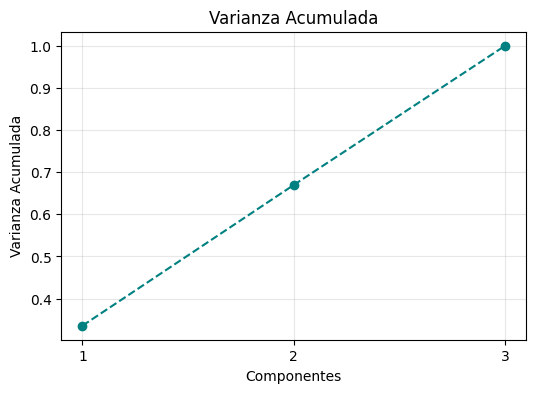

In [14]:
features_num = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X = df[features_num]

# 2. Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Ver varianza por componente
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Componente {i+1}: {var*100:.2f}% de varianza")

# Gráfico de varianza acumulada
plt.figure(figsize=(6, 4))
plt.plot(range(1, 4), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='teal')
plt.title('Varianza Acumulada')
plt.xlabel('Componentes')
plt.ylabel('Varianza Acumulada')
plt.xticks(range(1, 4))
plt.grid(True, alpha=0.3)
plt.show()

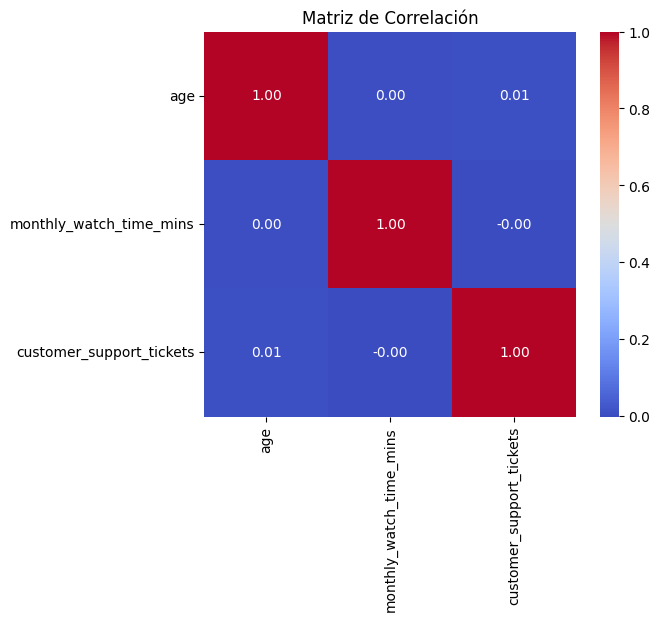

In [ ]:
correlation_matrix = X.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

**Justificación**: a través de la Matriz de Correlación y el Análisis de Componentes Principales (PCA), confirmamos que las variables numéricas de nuestros usuarios (**edad, minutos de visualización y tickets de soporte**) son completamente **independientes** entre sí.

En el mapa de calor se visualiza que no existe ninguna relación lineal entre ellas (correlaciones de 0.00), demostrando que el consumo o los problemas técnicos no están condicionados por la edad. Esta falta de correlación justifica conceptualmente por qué el PCA no es una técnica viable para reducir dimensiones en **este dataset**. Al no haber redundancia de información, cada componente principal explica exactamente la misma proporción de varianza (33% aprox.). Por lo tanto, para los próximos pasos de modelado predictivo o segmentación, la decisión técnica óptima del grupo es conservar las tres variables originales ya escaladas, garantizando que los algoritmos trabajen con el 100% de la información real y sin distorsiones.